In [1]:
import warnings
warnings.filterwarnings('ignore')

from IPython.core.display import display, HTML
display(HTML('<style>.container {width: 90% !important; }</style>'))

import glob, pyBigWig, shutil, os
import pandas as pd

import sys
sys.path.append('esvar/')
from esvar import esvar

### Bcell_GO_0035456 genetic

In [2]:
genetic  = "genetics_test/Bcell_GO_0035456.tsv"
es       = esvar(genetic=genetic, output="heatmap_test", collection_name="super_pbmc")
df_esvar = es.calculate_enrichment_score(less100=False, greater25k=False)
df_cover = es.get_coverage()

Removing NaN rows from loaded file ...
Calculating (1) total number of base-pairs within peaks and (2) total number of base-pairs within peaks divided by uniquely mappable base-pairs ...


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 19/19 [00:01<00:00, 10.07it/s]


Intersecting genetic with peak regions ...


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 19/19 [00:11<00:00,  1.63it/s]


For each fold, parallelised shuffling background ...
Calculating (1) total number of base-pairs within peaks and (2) total number of base-pairs within peaks divided by uniquely mappable base-pairs ...


...

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:59<00:00, 11.81s/it]


Calculating statistics ...
Adding shuffled background ...


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:59<00:00, 11.88s/it]


Calculating statistics ...
Cleaning temporary files ...
Processing genetics finished.
Removing NaN rows from loaded file ...
Getting coverage ...


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 19/19 [00:20<00:00,  1.06s/it]


### Heatmap plots

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
rounds = sorted(glob.glob("heatmap_test/rounds/statistics_intermediate_round*"))
esvar  = sorted(glob.glob("heatmap_test/statistics_ESVAR.csv"))

In [5]:
rounds

['heatmap_test/rounds/statistics_intermediate_round1.csv',
 'heatmap_test/rounds/statistics_intermediate_round2.csv',
 'heatmap_test/rounds/statistics_intermediate_round3.csv',
 'heatmap_test/rounds/statistics_intermediate_round4.csv',
 'heatmap_test/rounds/statistics_intermediate_round5.csv']

In [6]:
esvar

['heatmap_test/statistics_ESVAR.csv']

In [7]:
dfs = []
for r in rounds:
    df = pd.read_csv(r, sep='\t', index_col=0)
    df = df[['ESVAR']]
    name = r.split("/")[-1].replace(".csv", "")
    df.index = df.index + "_%s"%name
    dfs.append(df)
    
df = pd.concat(dfs)

print('min value:    ', df['ESVAR'].min())
print('mean value:   ', df['ESVAR'].mean())
print('median value: ', df['ESVAR'].median())
print('max value:    ', df['ESVAR'].max())

min value:     1.0634893665117344
mean value:    8.208224807895027
median value:  5.489046233614267
max value:     33.19947754940639


In [8]:
vmax = 0
for df in dfs:
    if df['ESVAR'].max() > vmax:
        vmax = df['ESVAR'].max()

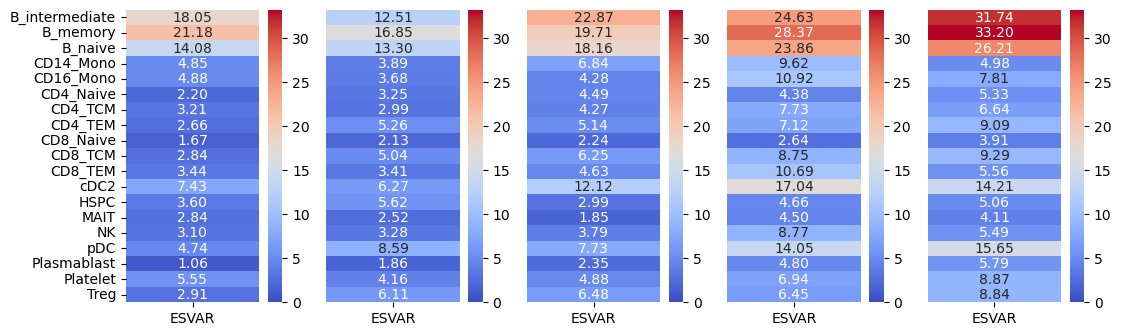

In [9]:
f, ax = plt.subplots(1,len(dfs),figsize=(len(dfs)*2.5,dfs[0].shape[0]/5))
for i, df in enumerate(dfs):
    if i == 0:
        df.index = df.index.str.replace("_statistics_intermediate_round1", "")
        ax[i] = sns.heatmap(df, annot=True, ax=ax[i], fmt='.2f', cmap='coolwarm', vmin=0, vmax=vmax)
    else:
        ax[i] = sns.heatmap(df, annot=True, ax=ax[i], yticklabels=False, fmt='.2f', cmap='coolwarm', vmin=0, vmax=vmax)
plt.show()

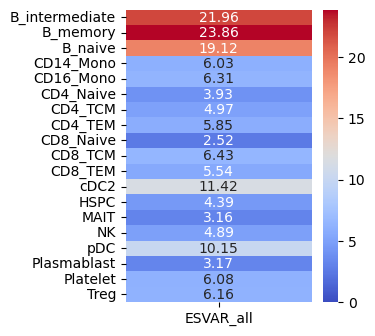

In [10]:
df = pd.read_csv(esvar[0], sep='\t', index_col=0)
f, ax = plt.subplots(1,1,figsize=(3,df.shape[0]/5))
ax = sns.heatmap(df, annot=True, ax=ax, fmt='.2f', cmap='coolwarm', vmin=0)
plt.show()